# 自作 AI モデルの比較評価（my_ai）

`india-ai-model` で作成したスコアのうち、候補 3 本（初期ベースライン `ridge__baseline`、単体最良 `dnn_peer_na_cpr_s10`、
最終候補 `ens_lgbm_dnn`）と、それぞれの EMA 平滑化版（`_hl1`、半減期 1 か月）を `alphaeval.report` で評価する。
参照として合成スコア `composite/comp_ew`（Composite v1）も同じ条件で並べる。

**規約**: 分位は **Q5 = スコア最上位**（Q1 = 最下位）。リターンは `drtn`（GEMLT `rtn`、INR 建て配当込みトータル）と
`srtn`（GEMLT 固有リターン）の 2 種類。累積は drtn が複利累積、srtn が累和。税は信託扱い税率・INR 建て、売買コスト 15/25bp、
バーンイン 12 か月。ベンチマークは MSCI India（時価総額ウェイト）。

india-ai-model 側の評価（rank IC 0.069 / 0.078 / 0.082）との違いは、リターン定義（mart の `drtn_1m` vs GEMLT 月次 `rtn`）と、
ロングオンリー（Q5 の対ベンチマーク超過）を主指標にする点。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, compute_alpha_report, india_tax_schedule, plot_cross_alpha_bars, plot_cumulative, summary_table

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

INPUT_ROOT = "../../input/msci_india_imi"
SCORES = {'ridge_baseline': 'my_ai/ridge__baseline', 'ridge_baseline_hl1': 'my_ai/ridge__baseline_hl1', 'dnn_peer_na_cpr_s10': 'my_ai/dnn_peer_na_cpr_s10', 'dnn_peer_na_cpr_s10_hl1': 'my_ai/dnn_peer_na_cpr_s10_hl1', 'ens_lgbm_dnn': 'my_ai/ens_lgbm_dnn', 'ens_lgbm_dnn_hl1': 'my_ai/ens_lgbm_dnn_hl1', 'comp_ew (参照)': 'composite/comp_ew'}
HIGHLIGHT = ['ens_lgbm_dnn', 'comp_ew (参照)']
BENCHMARK = "msci_india"
RISK_MODEL = "GEMLT"
RETURN_KINDS = {"drtn": "rtn", "srtn": "srtn"}   # 表示名 → return_list の id（drtn = 配当込みトータル、srtn = 固有）
START, END = 201212, 202606
N_QUANTILES = 5
BUFFER = 0.0
CW_MAX_WEIGHT = 0.05
COST_BUY, COST_SELL = 0.0015, 0.0025
FPI_TYPE = "trust"
BURN_IN = 12

store = InputStore(INPUT_ROOT)

## 1. 一括計算

`compute_alpha_report` でスコアごとに、Q5 EW 超過（対 MSCI India）、Q5 − Q1、Q5 CW 超過、税控除後 Q5 EW 超過、IC を drtn / srtn の両方で計算する。

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
returns = {kind: store.returns(RISK_MODEL, col, START, 202607) for kind, col in RETURN_KINDS.items()}
schedule = india_tax_schedule(FPI_TYPE)
scores = {name: store.alpha(path, START, END) for name, path in SCORES.items()}

reports = {}
for name, score in scores.items():
    reports[name] = compute_alpha_report(
        name, score, univ, bm, returns, n_quantiles=N_QUANTILES, buffer=BUFFER, cw_max_weight=CW_MAX_WEIGHT,
        tax_schedule=schedule, cost_buy=COST_BUY, cost_sell=COST_SELL, burn_in=BURN_IN, tax_kind="drtn",
    )
    print(f"{name:28s} done")
first = next(iter(reports.values()))
print(f"分位ラベル: 最上位 = {first.top}、最下位 = {first.bottom}。評価期間 {first.series['ew_excess']['drtn'].index.min().date()} 〜 {first.series['ew_excess']['drtn'].index.max().date()}")

ridge_baseline               done


ridge_baseline_hl1           done


dnn_peer_na_cpr_s10          done


dnn_peer_na_cpr_s10_hl1      done


ens_lgbm_dnn                 done


ens_lgbm_dnn_hl1             done


comp_ew (参照)                 done
分位ラベル: 最上位 = Q5、最下位 = Q1。評価期間 2014-01-31 〜 2026-07-31


## 2. 指標表

In [3]:
tbl = summary_table(reports)
print("指標表（年率。IC は平均。EW/CW = 等ウェイト / 時価総額ウェイト（上限 5%）、税後 = 売買コスト + 税控除後）")
display(tbl["drtn"].round(3))
display(tbl["srtn"].round(3))
display(tbl["共通"].round(3))

指標表（年率。IC は平均。EW/CW = 等ウェイト / 時価総額ウェイト（上限 5%）、税後 = 売買コスト + 税控除後）


指標,Q5 EW 超過 (vs BM),Q5 EW 超過 (vs BM) IR,Q5 − Q1,Q5 − Q1 IR,Q5 CW 超過 (vs BM),Q5 CW 超過 (vs BM) IR,税控除後 Q5 EW 超過 (vs BM),税控除後 Q5 EW 超過 (vs BM) IR,IC,ICIR,IC t
ridge_baseline,0.094,1.216,0.136,0.846,0.053,0.889,0.048,0.657,0.063,0.438,5.383
ridge_baseline_hl1,0.078,1.032,0.103,0.604,0.040,0.664,0.046,0.619,0.058,0.395,4.859
dnn_peer_na_cpr_s10,0.106,1.176,0.162,1.040,0.064,0.957,0.047,0.564,0.071,0.542,6.657
dnn_peer_na_cpr_s10_hl1,0.101,1.190,0.143,0.874,0.052,0.761,0.056,0.705,0.066,0.481,5.912
ens_lgbm_dnn,0.109,1.288,0.163,1.008,0.054,0.821,0.050,0.648,0.074,0.536,6.591
ens_lgbm_dnn_hl1,0.107,1.296,0.163,0.985,0.053,0.794,0.062,0.793,0.070,0.479,5.880
comp_ew (参照),0.132,1.157,0.173,1.314,0.096,1.082,0.080,0.740,0.054,0.480,5.901


指標,Q5 EW 超過 (vs BM),Q5 EW 超過 (vs BM) IR,Q5 − Q1,Q5 − Q1 IR,Q5 CW 超過 (vs BM),Q5 CW 超過 (vs BM) IR,税控除後 Q5 EW 超過 (vs BM),税控除後 Q5 EW 超過 (vs BM) IR,IC,ICIR,IC t
ridge_baseline,0.089,1.305,0.094,0.853,0.044,0.917,0.044,0.664,0.046,0.438,5.385
ridge_baseline_hl1,0.073,1.069,0.059,0.504,0.031,0.660,0.040,0.601,0.040,0.377,4.634
dnn_peer_na_cpr_s10,0.108,1.384,0.118,1.034,0.056,0.992,0.049,0.653,0.055,0.526,6.461
dnn_peer_na_cpr_s10_hl1,0.101,1.365,0.100,0.834,0.043,0.770,0.056,0.788,0.049,0.447,5.496
ens_lgbm_dnn,0.109,1.495,0.121,1.020,0.045,0.809,0.050,0.726,0.058,0.540,6.630
ens_lgbm_dnn_hl1,0.103,1.466,0.116,0.976,0.043,0.801,0.058,0.862,0.052,0.464,5.697
comp_ew (参照),0.115,1.141,0.107,0.972,0.065,0.790,0.064,0.644,0.032,0.314,3.861


指標,回転率 EW,回転率 CW,コストドラッグ,税ドラッグ,短期比率
ridge_baseline,3.557,2.974,0.015,0.029,0.827
ridge_baseline_hl1,2.059,1.598,0.008,0.023,0.654
dnn_peer_na_cpr_s10,5.271,5.390,0.021,0.036,0.952
dnn_peer_na_cpr_s10_hl1,3.003,2.920,0.012,0.031,0.855
ens_lgbm_dnn,5.165,5.057,0.021,0.036,0.938
ens_lgbm_dnn_hl1,2.965,2.844,0.012,0.030,0.825
comp_ew (参照),4.049,4.167,0.017,0.033,0.807


In [4]:
print("分位別の年率リターン（drtn、Q5 = 最上位）")
display(pd.DataFrame({name: rep.quantile_returns["drtn"].drop(columns="spread").mean() * 12 for name, rep in reports.items()}).T.round(3))

分位別の年率リターン（drtn、Q5 = 最上位）


,Q1,Q2,Q3,Q4,Q5
ridge_baseline,0.088,0.159,0.172,0.209,0.224
ridge_baseline_hl1,0.106,0.152,0.181,0.205,0.209
dnn_peer_na_cpr_s10,0.075,0.153,0.175,0.213,0.237
dnn_peer_na_cpr_s10_hl1,0.089,0.158,0.175,0.199,0.232
ens_lgbm_dnn,0.076,0.153,0.182,0.202,0.240
ens_lgbm_dnn_hl1,0.074,0.174,0.180,0.188,0.237
comp_ew (参照),0.090,0.138,0.165,0.197,0.262


## 3. 累積図

drtn は複利累積、srtn は累和。IC は累和と 36 か月移動平均。

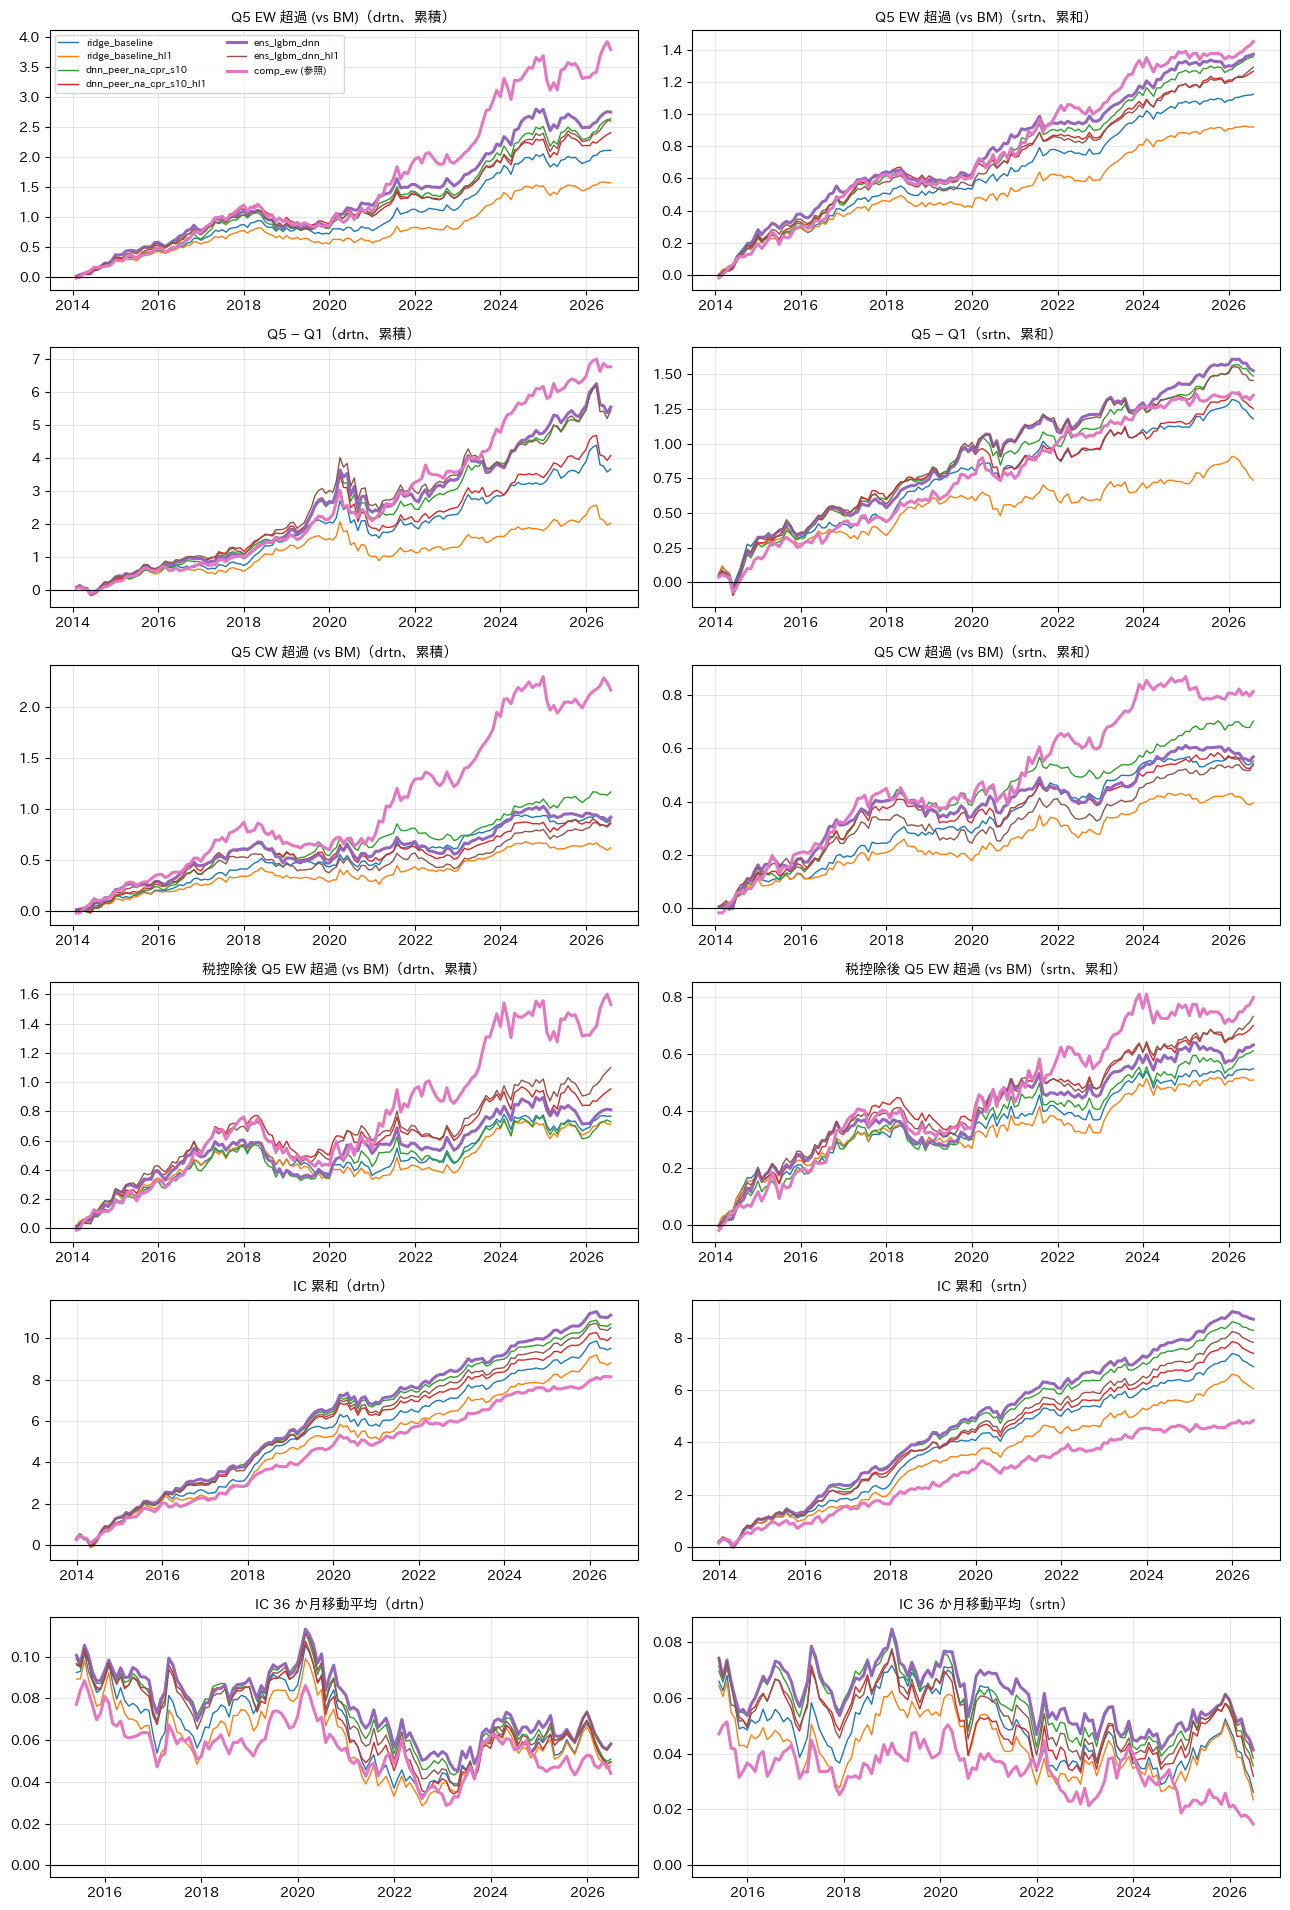

In [5]:
fig = plot_cumulative(reports, highlight=HIGHLIGHT)
plt.show()

## 4. アルファ横断の棒グラフ（年率、IC は平均）

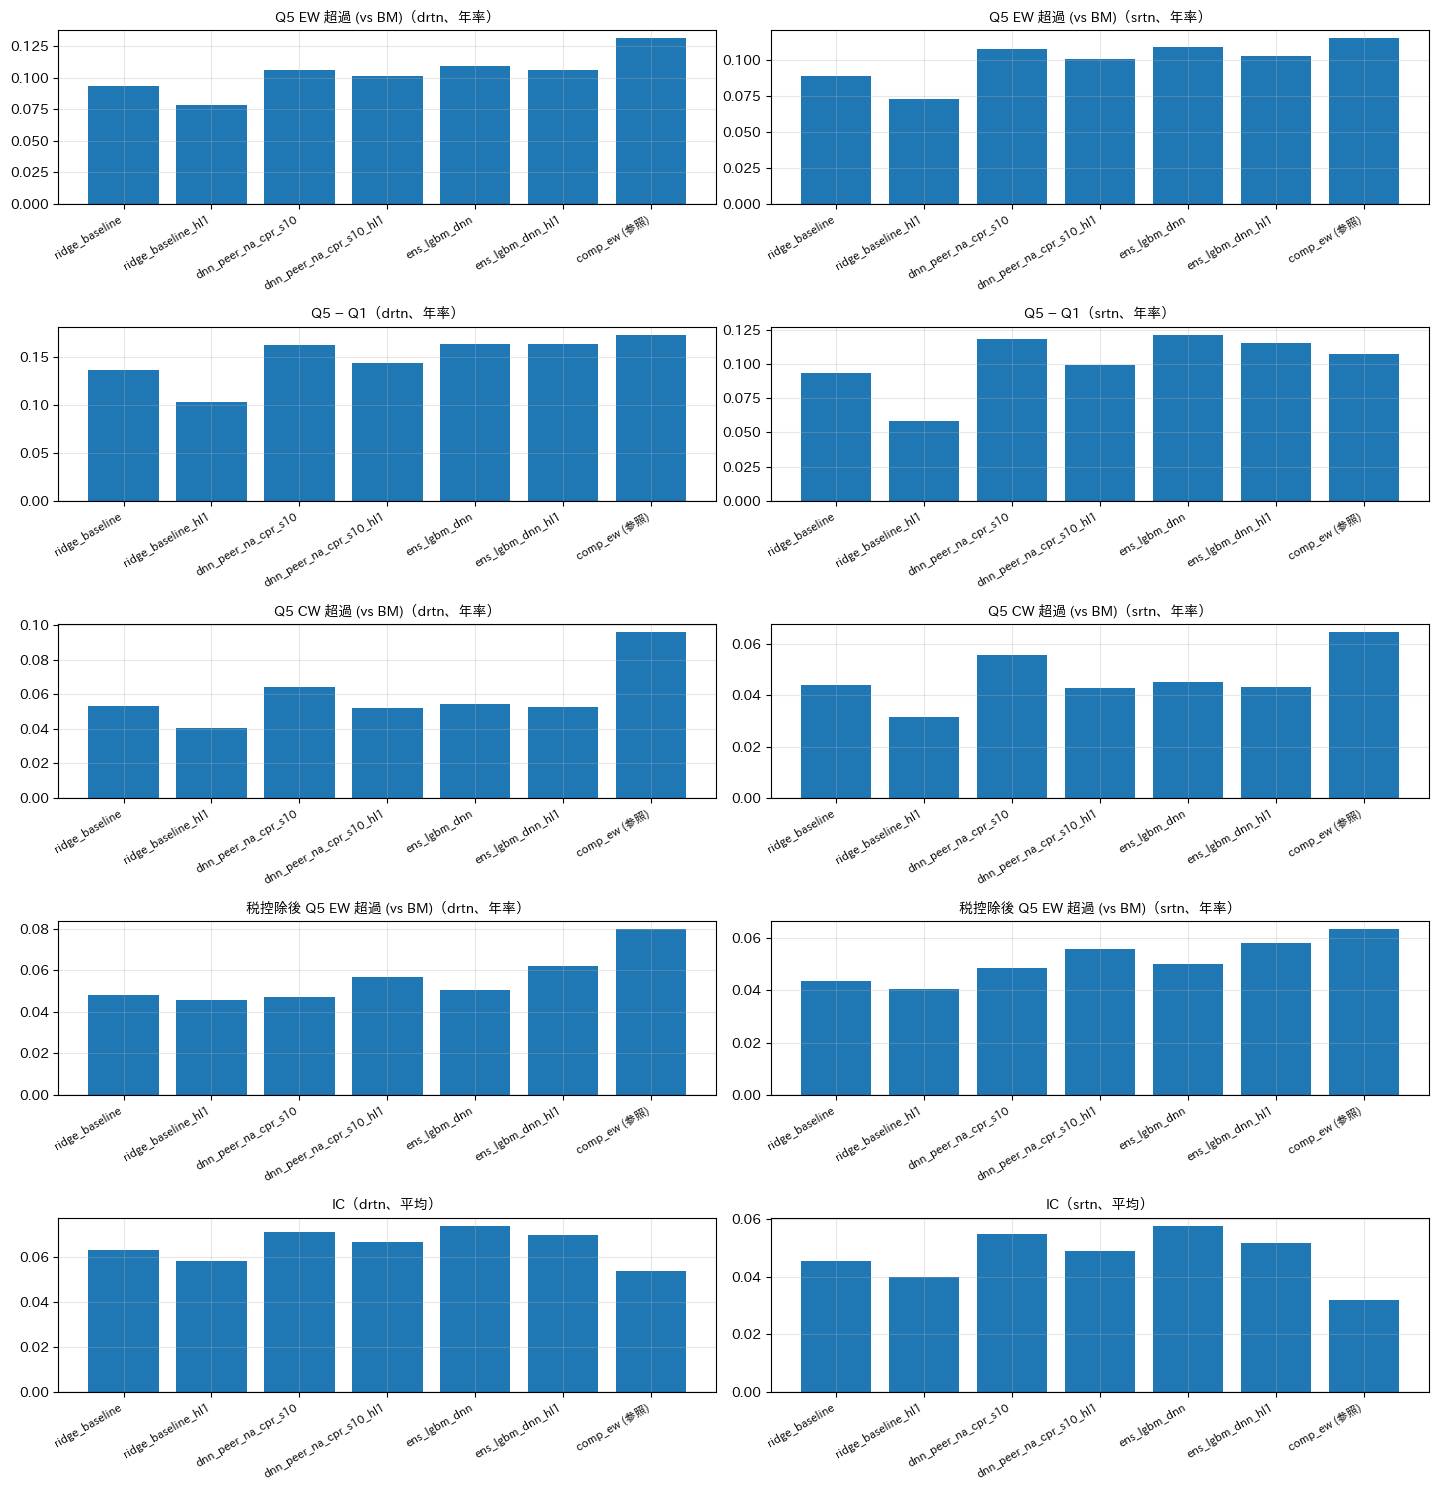

In [6]:
fig = plot_cross_alpha_bars(reports)
plt.show()

## 所見

評価期間は 2014-01〜2026-07（バーンイン 12 か月後）。分位は Q5 = 最上位。

**drtn（配当込みトータルリターン）**

| | IC | ICIR | Q5 EW 超過 | IR | Q5−Q1 | Q5 CW 超過 | 税後 Q5 EW 超過 | 税後 IR | 回転率 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ridge_baseline | 0.063 | 0.44 | 9.4% | 1.22 | 13.6% | 5.3% | 4.8% | 0.66 | 356% |
| dnn_peer_na_cpr_s10 | 0.071 | 0.54 | 10.6% | 1.18 | 16.2% | 6.4% | 4.7% | 0.56 | 527% |
| ens_lgbm_dnn | 0.074 | 0.54 | 10.9% | 1.29 | 16.3% | 5.4% | 5.0% | 0.65 | 517% |
| ens_lgbm_dnn_hl1 | 0.070 | 0.48 | 10.7% | 1.30 | 16.3% | 5.3% | 6.2% | 0.79 | 297% |
| comp_ew（参照） | 0.054 | 0.48 | 13.2% | 1.16 | 17.3% | 9.6% | 8.0% | 0.74 | 405% |

- 3 本の序列は IC・Q5 超過・税後 IR のいずれでも `ens_lgbm_dnn > dnn_peer_na_cpr_s10 > ridge_baseline`。
  india-ai-model 側の rank IC（0.069 / 0.078 / 0.082）とはバーンインとリターン定義の差で 0.006〜0.008 低いが、順序は同じ。
- **ロングオンリーの Q5 EW 超過・CW 超過・税後では `comp_ew` が AI モデルを上回る**（13.2% vs 10.9%、CW 9.6% vs 5.4%、税後 8.0% vs 5.0%）。
  AI モデルは IC は高いが、最上位 20% に集中する超過と大型株での超過が小さく、回転率が高い。
- 平滑化（`_hl1`）は IC を 0.004 下げる一方、回転率を 517% → 297% に半減させ、税後超過を 5.0% → 6.2%、税後 IR を 0.65 → 0.79 に改善する。
  AI モデル単体で使うなら平滑化版が優位。

**srtn（固有リターン）**

- Q5 EW 超過は AI モデル 10.3〜10.9%（IR 1.47〜1.50）、`comp_ew` 11.5%（IR 1.14）。固有リターンで見ると AI モデルの IR は `comp_ew` より高く、
  AI モデルの超過はファクターに依存しない成分が多い。
- IC（srtn）は AI モデル 0.052〜0.058 に対し `comp_ew` 0.032（t 3.9）。`comp_ew` の IC の 4 割はファクター寄与で説明される。
- 一方 Q5 CW 超過（srtn）は AI 4.3〜5.6% vs `comp_ew` 6.5% で、大型株での固有超過は `comp_ew` が上。

**判断**

1. 単体採用なら `ens_lgbm_dnn_hl1`（税後 IR 0.79、回転率 297%）。生スコアは回転率 517% と高く、税後で平滑化版に劣る。
2. ロングオンリー・税後の主指標では `comp_ew` に届かないが、固有リターンでの IR は AI が高く、両者の情報源が異なる。
   `02_blend_comp_ai` で合成を検討する。